In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [3]:
train_dir = path + "/brain_tumor_dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [4]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
#compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [6]:
#training
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 606ms/step - accuracy: 0.7241 - loss: 0.7944 - val_accuracy: 0.7400 - val_loss: 0.5074
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 446ms/step - accuracy: 0.8571 - loss: 0.3934 - val_accuracy: 0.7600 - val_loss: 0.5463
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 882ms/step - accuracy: 0.8768 - loss: 0.3044 - val_accuracy: 0.8600 - val_loss: 0.4925
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 615ms/step - accuracy: 0.9557 - loss: 0.1725 - val_accuracy: 0.7800 - val_loss: 0.5343
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 429ms/step - accuracy: 0.9803 - loss: 0.0948 - val_accuracy: 0.8000 - val_loss: 0.5617
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 562ms/step - accuracy: 0.9704 - loss: 0.0506 - val_accuracy: 0.9000 - val_loss: 0.4412
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 458ms/step - accuracy: 0.9901 - loss: 0.0300 - val_accuracy: 0.8200 - val_loss: 0.6494
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 552ms/step - accuracy: 1.0000 - loss: 0.0098 - val_accuracy: 

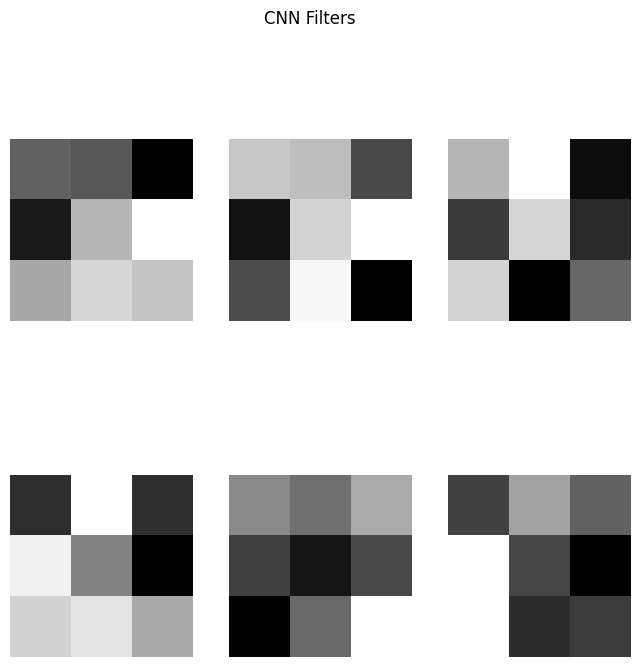

In [7]:
#filter visualization
filters, biases = model.layers[0].get_weights()

plt.figure(figsize=(8,8))

for i in range(6):
    f = filters[:,:,:,i]
    plt.subplot(2,3,i+1)
    plt.imshow(f[:,:,0], cmap='gray')
    plt.axis('off')

plt.suptitle("CNN Filters")
plt.show()

In [8]:
#evaluation
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.8600 - loss: 0.5645 
Validation Accuracy: 0.8600000143051147
Validation Loss: 0.5644763708114624


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

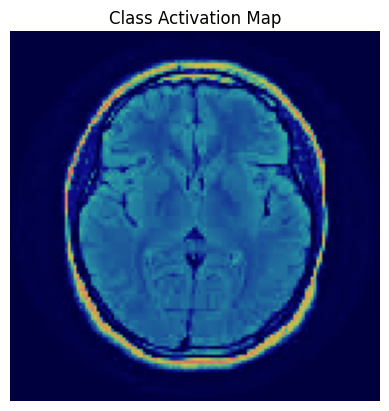

In [9]:
import cv2

img = train_data[0][0][0]

heatmap = np.mean(img, axis=-1)

plt.imshow(img)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.title("Class Activation Map")
plt.axis('off')